In [2]:
pip install tensorflow-macos tensorflow-metal

  Using cached tensorflow-2.16.2-cp310-cp310-macosx_12_0_arm64.whl.metadata (4.1 kB)
  Using cached ml_dtypes-0.3.2-cp310-cp310-macosx_10_9_universal2.whl.metadata (20 kB)
  Using cached protobuf-4.25.8-cp37-abi3-macosx_10_9_universal2.whl.metadata (541 bytes)
  Using cached tensorboard-2.16.2-py3-none-any.whl.metadata (1.6 kB)
Using cached tensorflow-2.16.2-cp310-cp310-macosx_12_0_arm64.whl (227.0 MB)
Using cached ml_dtypes-0.3.2-cp310-cp310-macosx_10_9_universal2.whl (389 kB)
Using cached protobuf-4.25.8-cp37-abi3-macosx_10_9_universal2.whl (394 kB)
Using cached tensorboard-2.16.2-py3-none-any.whl (5.5 MB)
  Attempting uninstall: protobuf
    Found existing installation: protobuf 6.33.2
    Uninstalling protobuf-6.33.2:
      Successfully uninstalled protobuf-6.33.2
  Attempting uninstall: ml-dtypes
    Found existing installation: ml_dtypes 0.5.4
    Uninstalling ml_dtypes-0.5.4:
      Successfully uninstalled ml_dtypes-0.5.4
  Attempting uninstall: tensorboard
    Found existing in

In [2]:
pip uninstall -y numpy

Found existing installation: numpy 2.2.6
Uninstalling numpy-2.2.6:
  Successfully uninstalled numpy-2.2.6
Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install "numpy==1.26.4"

  Using cached numpy-1.26.4-cp310-cp310-macosx_11_0_arm64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp310-cp310-macosx_11_0_arm64.whl (14.0 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
tf-keras 2.20.1 requires tensorflow<2.21,>=2.20, but you have tensorflow 2.16.2 which is incompatible.
Note: you may need to restart the kernel to use updated packages.


In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf

In [3]:
# we have resized the image and created a batch of size 32.
train_ds = tf.keras.utils.image_dataset_from_directory(
    "state-farm-distracted-driver-detection/imgs/train",
    image_size=(224, 224),
    batch_size=32,
    shuffle=True,
    validation_split=0.2,   
    subset="training",      
    seed=42                 
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    "state-farm-distracted-driver-detection/imgs/train",
    image_size=(224, 224),
    batch_size=32,
    shuffle=True,
    validation_split=0.2,   
    subset="validation",     
    seed=42
)

Found 22424 files belonging to 10 classes.
Using 17940 files for training.


2025-12-24 05:38:40.734182: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M3
2025-12-24 05:38:40.734321: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 8.00 GB
2025-12-24 05:38:40.734325: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 2.67 GB
2025-12-24 05:38:40.734598: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-12-24 05:38:40.734615: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Found 22424 files belonging to 10 classes.
Using 4484 files for validation.


In [4]:
#"take(1)" here means selecting the first batch in the train dataset. And prints labels of 10 images of that batch.
for images, labels in train_ds.take(1):
    print(images.shape, labels[:5])

(32, 224, 224, 3) tf.Tensor([6 4 5 9 6], shape=(5,), dtype=int32)


2025-12-07 19:52:50.801168: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [4]:
train_ds = train_ds.map(lambda x, y: (x/255.0, y))
val_ds = val_ds.map(lambda x, y: (x/255.0, y))

Baseline CNN with two cnn blocks followed by a flattened and two dense layers.

In [7]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(224, 224, 3)),
    
    tf.keras.layers.Conv2D(32, (3,3), padding='same'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.ReLU(),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64, (3,3), padding='same'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.ReLU(),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax') 
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 200704)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │    12,845,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,865,546 (49.08 MB)

 Trainable params: 12,865,354 (49.08 MB)

 Non-trainable params: 192 (768.00 B)

In [9]:
#I have re-used the lab codes here. 
checkpoint= tf.keras.callbacks.ModelCheckpoint("Best_baseline_CNN.keras",save_best_only=True, monitor="val_loss")
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, min_delta=1e-4, restore_best_weights=True)

history = model.fit(
    train_ds,
    validation_data = val_ds,
    epochs=10,
    callbacks = [checkpoint, early_stopping]
)

Epoch 1/10


2025-12-07 19:54:46.841045: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


561/561 ━━━━━━━━━━━━━━━━━━━━ 133s 233ms/step - accuracy: 0.4867 - loss: 25.8139 - val_accuracy: 0.5515 - val_loss: 10.8621
Epoch 2/10
561/561 ━━━━━━━━━━━━━━━━━━━━ 137s 243ms/step - accuracy: 0.8003 - loss: 4.8793 - val_accuracy: 0.8657 - val_loss: 2.8172
Epoch 3/10
561/561 ━━━━━━━━━━━━━━━━━━━━ 134s 238ms/step - accuracy: 0.9129 - loss: 1.9409 - val_accuracy: 0.8921 - val_loss: 2.7280
Epoch 4/10
561/561 ━━━━━━━━━━━━━━━━━━━━ 135s 240ms/step - accuracy: 0.9455 - loss: 1.1816 - val_accuracy: 0.9126 - val_loss: 2.6528
Epoch 5/10
561/561 ━━━━━━━━━━━━━━━━━━━━ 138s 246ms/step - accuracy: 0.9582 - loss: 0.9823 - val_accuracy: 0.8093 - val_loss: 5.9283
Epoch 6/10
561/561 ━━━━━━━━━━━━━━━━━━━━ 139s 247ms/step - accuracy: 0.9606 - loss: 0.9656 - val_accuracy: 0.9141 - val_loss: 2.6537
Epoch 7/10
561/561 ━━━━━━━━━━━━━━━━━━━━ 137s 243ms/step - accuracy: 0.9709 - loss: 0.7027 - val_accuracy: 0.9471 - val_loss: 1.7572
Epoch 8/10
561/561 ━━━━━━━━━━━━━━━━━━━━ 134s 239ms/step - accuracy: 0.9779 - loss: 0.

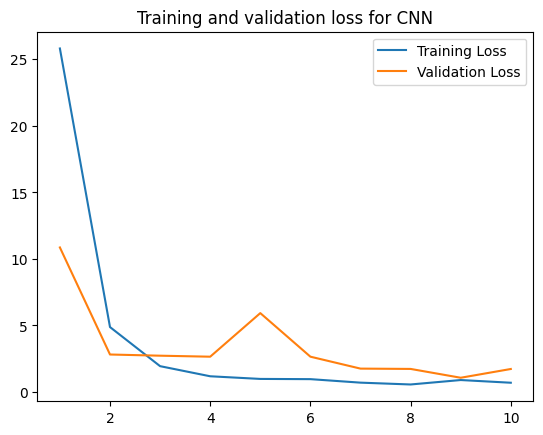

In [14]:
import matplotlib.pyplot as plt

train_loss_CNN = history.history['loss']
val_loss_CNN = history.history['val_loss']
epoch = range(1, len(train_loss_CNN) + 1)

plt.plot(epoch, train_loss_CNN, label = 'Training Loss')
plt.plot(epoch, val_loss_CNN, label = 'Validation Loss')
plt.title('Training and validation loss for CNN')
plt.legend()

plt.show()

Pretrained MobileNet on imagenet dataset. Very fast and less computationaly expensive due to the depth wise separable concept.So, 
basically it breaks the general step into two parts - firstly, applying filters across each of the three channels separately. Secondly,
1x1 conv to allow sharing of information among different channels.


In [5]:
MobileNet = tf.keras.applications.MobileNet(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

In [6]:
MobileNet.trainable =False
MobileNet.summary()

Model: "mobilenet_1.00_224"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 112, 112, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_bn (BatchNormalization)   │ (None, 112, 112, 32)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_relu (ReLU)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1 (DepthwiseConv2D)     │ (None, 112, 112, 32)   │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1_bn                    │ (None, 112, 112, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1_relu (ReLU)           │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1 (Conv2D)              │ (None, 112, 112, 64)   │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1_bn                    │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1_relu (ReLU)           │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pad_2 (ZeroPadding2D)      │ (None, 113, 113, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2 (DepthwiseConv2D)     │ (None, 56, 56, 64)     │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2_bn                    │ (None, 56, 56, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2_relu (ReLU)           │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2 (Conv2D)              │ (None, 56, 56, 128)    │         8,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2_bn                    │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2_relu (ReLU)           │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3 (DepthwiseConv2D)     │ (None, 56, 56, 128)    │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3_bn                    │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3_relu (ReLU)           │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_3 (Conv2D)              │ (None, 56, 56, 128)    │        16,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_3_bn                    │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │             

 Total params: 3,228,864 (12.32 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 3,228,864 (12.32 MB)

In [7]:
def build_pretrained(input_shape):
    input = tf.keras.Input(shape=input_shape)
    x = MobileNet(input)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dense(128, activation='relu')(x)
    output = tf.keras.layers.Dense(10, activation='softmax')(x)

    model = tf.keras.Model(inputs=input, outputs=output)
    return model

Pretrained_MobileNet=build_pretrained(input_shape=(224,224,3))
print(Pretrained_MobileNet.summary())

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenet_1.00_224 (Functional) │ (None, 7, 7, 1024)     │     3,228,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,361,354 (12.82 MB)

 Trainable params: 132,490 (517.54 KB)

 Non-trainable params: 3,228,864 (12.32 MB)

None


In [8]:
Pretrained_MobileNet.compile(
    optimizer = 'adam',
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

In [9]:
checkpoint= tf.keras.callbacks.ModelCheckpoint("MobileNet.keras",save_best_only=True, monitor="val_loss")
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, min_delta=1e-4, restore_best_weights=True)

history_MobileNet = Pretrained_MobileNet.fit(
    train_ds,
    validation_data = val_ds,
    epochs = 10,
    callbacks =[early_stopping, checkpoint]
)

Epoch 1/10


2025-12-24 05:39:56.255701: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


561/561 ━━━━━━━━━━━━━━━━━━━━ 66s 115ms/step - accuracy: 0.8186 - loss: 0.6341 - val_accuracy: 0.9581 - val_loss: 0.1900
Epoch 2/10
561/561 ━━━━━━━━━━━━━━━━━━━━ 64s 114ms/step - accuracy: 0.9617 - loss: 0.1421 - val_accuracy: 0.9748 - val_loss: 0.1047
Epoch 3/10
561/561 ━━━━━━━━━━━━━━━━━━━━ 63s 112ms/step - accuracy: 0.9771 - loss: 0.0847 - val_accuracy: 0.9739 - val_loss: 0.1024
Epoch 4/10
561/561 ━━━━━━━━━━━━━━━━━━━━ 63s 113ms/step - accuracy: 0.9824 - loss: 0.0635 - val_accuracy: 0.9730 - val_loss: 0.1004
Epoch 5/10
561/561 ━━━━━━━━━━━━━━━━━━━━ 67s 120ms/step - accuracy: 0.9861 - loss: 0.0508 - val_accuracy: 0.9819 - val_loss: 0.0717
Epoch 6/10
561/561 ━━━━━━━━━━━━━━━━━━━━ 72s 128ms/step - accuracy: 0.9899 - loss: 0.0357 - val_accuracy: 0.9632 - val_loss: 0.1226
Epoch 7/10
561/561 ━━━━━━━━━━━━━━━━━━━━ 69s 122ms/step - accuracy: 0.9902 - loss: 0.0327 - val_accuracy: 0.9804 - val_loss: 0.0771
Epoch 8/10
561/561 ━━━━━━━━━━━━━━━━━━━━ 68s 122ms/step - accuracy: 0.9884 - loss: 0.0368 - val

In [11]:
Pretrained_MobileNet.save("MobileNet1.h5")

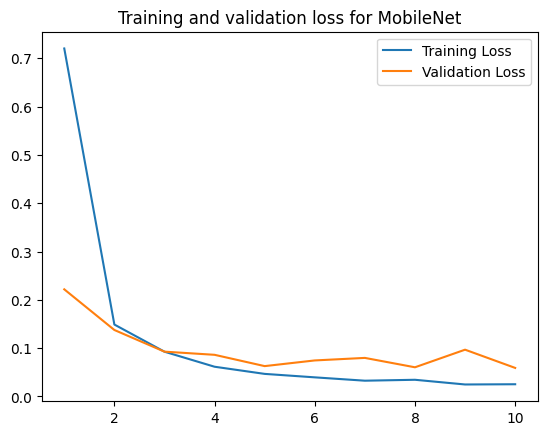

In [22]:
train_loss_MobileNet = history_MobileNet.history['loss']
val_loss_MobileNet = history_MobileNet.history['val_loss']

plt.plot(epoch, train_loss_MobileNet, label = 'Training Loss')
plt.plot(epoch, val_loss_MobileNet, label = 'Validation Loss')
plt.title('Training and validation loss for MobileNet')
plt.legend()

plt.show()

Fine-tuned MobileNet by freezing the last 30 layers of the model.

from tensorflow import keras
from keras import layers
for i, layers in enumerate(Pretrained_MobileNet.layers):
    print(i, layers.name)

In [21]:
for layers in Pretrained_MobileNet.layers[-30:]:
    layers.trainable = True

In [22]:
Pretrained_MobileNet.summary()
optimizer = tf.keras.optimizers.Adam(1e-4)
Pretrained_MobileNet.compile(
    optimizer = optimizer,
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenet_1.00_224 (Functional) │ (None, 7, 7, 1024)     │     3,228,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,361,354 (12.82 MB)

 Trainable params: 3,339,466 (12.74 MB)

 Non-trainable params: 21,888 (85.50 KB)

In [25]:
checkpoint= tf.keras.callbacks.ModelCheckpoint("Tuned-MobileNet.keras",save_best_only=True, monitor="val_loss")
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, min_delta=1e-4, restore_best_weights=True)

history_Finetuned_MobileNet = Pretrained_MobileNet.fit(
    train_ds,
    validation_data = val_ds,
    epochs = 10,
    callbacks = [early_stopping, checkpoint]
)

Epoch 1/10
561/561 ━━━━━━━━━━━━━━━━━━━━ 406s 707ms/step - accuracy: 0.9371 - loss: 0.4020 - val_accuracy: 0.9761 - val_loss: 0.1332
Epoch 2/10
561/561 ━━━━━━━━━━━━━━━━━━━━ 412s 734ms/step - accuracy: 0.9898 - loss: 0.0373 - val_accuracy: 0.9670 - val_loss: 0.1656
Epoch 3/10
561/561 ━━━━━━━━━━━━━━━━━━━━ 446s 795ms/step - accuracy: 0.9937 - loss: 0.0245 - val_accuracy: 0.9815 - val_loss: 0.1080
Epoch 4/10
561/561 ━━━━━━━━━━━━━━━━━━━━ 401s 714ms/step - accuracy: 0.9914 - loss: 0.0347 - val_accuracy: 0.9639 - val_loss: 0.1953
Epoch 5/10
561/561 ━━━━━━━━━━━━━━━━━━━━ 404s 721ms/step - accuracy: 0.9908 - loss: 0.0364 - val_accuracy: 0.9815 - val_loss: 0.1288
Epoch 6/10
561/561 ━━━━━━━━━━━━━━━━━━━━ 395s 703ms/step - accuracy: 0.9940 - loss: 0.0219 - val_accuracy: 0.9784 - val_loss: 0.1245
Epoch 7/10
561/561 ━━━━━━━━━━━━━━━━━━━━ 411s 732ms/step - accuracy: 0.9917 - loss: 0.0318 - val_accuracy: 0.9764 - val_loss: 0.1403
Epoch 8/10
561/561 ━━━━━━━━━━━━━━━━━━━━ 415s 739ms/step - accuracy: 0.9934 -

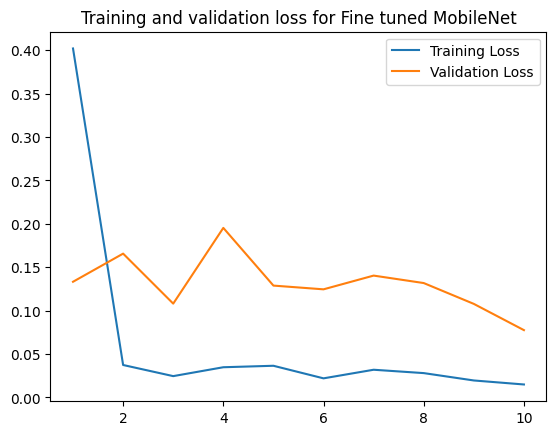

In [27]:
train_loss_Fine_MobileNet = history_Finetuned_MobileNet.history['loss']
val_loss_Fine_MobileNet = history_Finetuned_MobileNet.history['val_loss']

plt.plot(epoch, train_loss_Fine_MobileNet, label = 'Training Loss')
plt.plot(epoch, val_loss_Fine_MobileNet, label = 'Validation Loss')
plt.title('Training and validation loss for Fine tuned MobileNet')
plt.legend()

plt.show()

Simple Vision Transformer

Saw a couple of youtube videos and used GPT to learn about vision tranformer, how do they work and how to build a simple one from scratch.
Firstly, we convert image into patches that is later flattened into a vector conatining pixel values of all the patches.
Secondly, adding a position vector with the vectors(embedding) created in the first step.
Thirdly, passing this resulted vector through transformer encoder block to learn features and relations.
Lastly, passing the output through a classification head that would give us the desired results.

In [6]:
class PatchLayer(tf.keras.layers.Layer):
    def __init__(self, patch_size):
        super().__init__()
        self.patch_size = patch_size

    def call(self, images):
        batch_size = tf.shape(images)[0]
        patches = tf.image.extract_patches(
            images=images,
            sizes=[1, self.patch_size, self.patch_size, 1],
            strides=[1, self.patch_size, self.patch_size, 1],
            rates=[1, 1, 1, 1],
            padding='VALID'
        )
        patch_dim = patches.shape[-1]
        patches = tf.reshape(patches, [batch_size, -1, patch_dim])
        return patches

In [7]:
class PatchEmbedding(tf.keras.layers.Layer):
    def __init__(self, num_patches, embed_dim):
        super().__init__()
        self.projection = tf.keras.layers.Dense(embed_dim)
        self.pos_embedding = tf.keras.layers.Embedding(
            input_dim=num_patches, output_dim=embed_dim
        )

    def call(self, patches):
        positions = tf.range(start=0, limit=tf.shape(patches)[1], delta=1)
        return self.projection(patches) + self.pos_embedding(positions)

In [8]:
class TransformerEncoder(tf.keras.layers.Layer):
    def __init__(self, embed_dim, num_heads, mlp_dim):
        super().__init__()
        self.attn = tf.keras.layers.MultiHeadAttention(
            num_heads=num_heads, key_dim=embed_dim
        )
        self.norm1 = tf.keras.layers.LayerNormalization()
        self.mlp = tf.keras.Sequential([
            tf.keras.layers.Dense(mlp_dim, activation='relu'),
            tf.keras.layers.Dense(embed_dim),
        ])
        self.norm2 = tf.keras.layers.LayerNormalization()

    def call(self, x):
        attn_output = self.attn(x, x)  
        x = self.norm1(x + attn_output)

        mlp_output = self.mlp(x)
        return self.norm2(x + mlp_output)


In [8]:
def build_simple_vit(
        image_size=224,
        patch_size=16,
        embed_dim=64,
        num_heads=4,
        mlp_dim=128,
        num_layers=4,
        num_classes=10):

    num_patches = (image_size // patch_size) ** 2

    inputs = tf.keras.Input((image_size, image_size, 3))

    # 1. Create patches
    patches = PatchLayer(patch_size)(inputs)

    # 2. Embed patches
    x = PatchEmbedding(num_patches, embed_dim)(patches)

    # 3. Transformer blocks
    for _ in range(num_layers):
        x = TransformerEncoder(embed_dim, num_heads, mlp_dim)(x)

    # 4. Classification head
    x = tf.keras.layers.LayerNormalization()(x)
    x = tf.keras.layers.GlobalAveragePooling1D()(x)
    outputs = tf.keras.layers.Dense(num_classes, activation='softmax')(x)

    model = tf.keras.Model(inputs, outputs)
    return model


In [9]:
vit = build_simple_vit()
vit.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate= 0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

vit.summary()


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ patch_layer (PatchLayer)        │ (None, None, 768)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ patch_embedding                 │ (None, None, 64)       │        61,760 │
│ (PatchEmbedding)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_encoder             │ (None, None, 64)       │        83,200 │
│ (TransformerEncoder)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_encoder_1           │ (None, None, 64)       │        83,200 │
│ (TransformerEncoder)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_encoder_2           │ (None, None, 64)       │        83,200 │
│ (TransformerEncoder)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_encoder_3           │ (None, None, 64)       │        83,200 │
│ (TransformerEncoder)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_8           │ (None, None, 64)       │           128 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 395,338 (1.51 MB)

 Trainable params: 395,338 (1.51 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
checkpoint= tf.keras.callbacks.ModelCheckpoint("Best_baseline_transformer.keras",save_best_only=True, monitor="val_loss")
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=4, min_delta=1e-4, restore_best_weights=True)

history_vit = vit.fit(
    train_ds,
    validation_data = val_ds,
    epochs=10,
    callbacks = [checkpoint, early_stopping]
)

Epoch 1/10


2025-12-08 15:35:06.648762: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


561/561 ━━━━━━━━━━━━━━━━━━━━ 197s 343ms/step - accuracy: 0.0992 - loss: 2.3377 - val_accuracy: 0.1064 - val_loss: 2.3303
Epoch 2/10
561/561 ━━━━━━━━━━━━━━━━━━━━ 201s 359ms/step - accuracy: 0.1050 - loss: 2.3148 - val_accuracy: 0.1128 - val_loss: 2.3095
Epoch 3/10
561/561 ━━━━━━━━━━━━━━━━━━━━ 204s 362ms/step - accuracy: 0.1031 - loss: 2.3127 - val_accuracy: 0.0879 - val_loss: 2.3096
Epoch 4/10
561/561 ━━━━━━━━━━━━━━━━━━━━ 201s 359ms/step - accuracy: 0.1055 - loss: 2.3095 - val_accuracy: 0.1075 - val_loss: 2.3119
Epoch 5/10
561/561 ━━━━━━━━━━━━━━━━━━━━ 218s 388ms/step - accuracy: 0.1017 - loss: 2.3093 - val_accuracy: 0.0879 - val_loss: 2.3091
Epoch 6/10
561/561 ━━━━━━━━━━━━━━━━━━━━ 233s 415ms/step - accuracy: 0.1052 - loss: 2.3099 - val_accuracy: 0.0879 - val_loss: 2.3086
Epoch 7/10
561/561 ━━━━━━━━━━━━━━━━━━━━ 233s 416ms/step - accuracy: 0.1028 - loss: 2.3094 - val_accuracy: 0.1075 - val_loss: 2.3052
Epoch 8/10
561/561 ━━━━━━━━━━━━━━━━━━━━ 232s 413ms/step - accuracy: 0.1051 - loss: 2.30

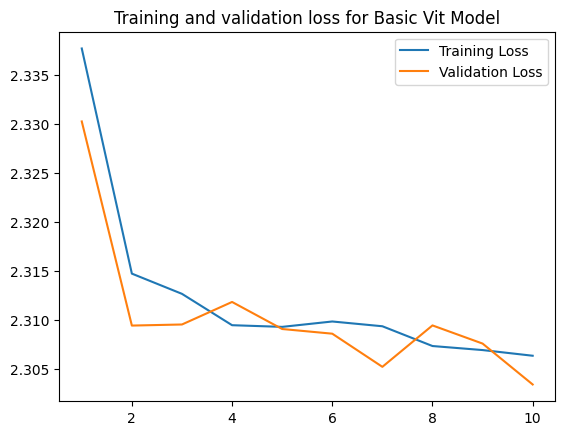

In [14]:
import matplotlib.pyplot as plt

train_loss_vit = history_vit.history['loss']
val_loss_vit = history_vit.history['val_loss']
epoch = range(1, len(train_loss_vit) + 1)

plt.plot(epoch, train_loss_vit, label = 'Training Loss')
plt.plot(epoch, val_loss_vit, label = 'Validation Loss')
plt.title('Training and validation loss for Basic Vit Model')
plt.legend()

plt.show()

Data Augmenting

In [15]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rotation_range=10,          
    width_shift_range=0.1,      
    height_shift_range=0.1,     
    horizontal_flip=True        
)

train_ds_new = train_datagen.flow_from_directory(
    "state-farm-distracted-driver-detection/imgs/train",
    target_size=(224, 224),
    batch_size=32,
    class_mode='sparse'         # because labels are integer classes
)

Found 22424 images belonging to 10 classes.


In [ ]:
checkpoint= tf.keras.callbacks.ModelCheckpoint("Tuned-MobileNet_augment.keras",save_best_only=True, monitor="val_loss")
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, min_delta=1e-4, restore_best_weights=True)

history_Finetuned_MobileNet_Augmentation = Pretrained_MobileNet.fit(
    train_ds_new,
    validation_data = val_ds,
    epochs = 10,
    callbacks = [early_stopping, checkpoint]
)

Epoch 1/10
701/701 ━━━━━━━━━━━━━━━━━━━━ 645s 907ms/step - accuracy: 0.9134 - loss: 0.3162 - val_accuracy: 0.1091 - val_loss: 3.1825
Epoch 2/10
701/701 ━━━━━━━━━━━━━━━━━━━━ 567s 792ms/step - accuracy: 0.9786 - loss: 0.0792 - val_accuracy: 0.1113 - val_loss: 4.0377
Epoch 3/10
152/701 ━━━━━━━━━━━━━━━━━━━━ 6:35 720ms/step - accuracy: 0.9816 - loss: 0.0713

In [9]:
def build_simple_vit_conv(
        image_size=224,
        patch_size=16,
        embed_dim=64,
        num_heads=4,
        mlp_dim=128,
        num_layers=4,
        num_classes=10):

    num_patches = (image_size // patch_size) ** 2

    inputs = tf.keras.Input((image_size, image_size, 3))

    # ----------------------------------------------------
    # ⭐ NEW: Convolution stem (learn spatial features)
    # ----------------------------------------------------
    x = tf.keras.layers.Conv2D(32, 3, padding="same")(inputs)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.ReLU()(x)

    # 1. Create patches (now created from CNN feature maps)
    patches = PatchLayer(patch_size)(x)

    # 2. Embed patches
    x = PatchEmbedding(num_patches, embed_dim)(patches)

    # 3. Transformer Encoder blocks
    for _ in range(num_layers):
        x = TransformerEncoder(embed_dim, num_heads, mlp_dim)(x)

    # 4. Classification Head
    x = tf.keras.layers.LayerNormalization()(x)
    x = tf.keras.layers.GlobalAveragePooling1D()(x)
    outputs = tf.keras.layers.Dense(num_classes, activation="softmax")(x)

    model = tf.keras.Model(inputs, outputs)
    return model

In [10]:
conv_vit = build_simple_vit_conv()
conv_vit.compile(
    optimizer = tf.keras.optimizers.Adam(),
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

conv_vit.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ patch_layer (PatchLayer)        │ (None, None, 8192)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ patch_embedding                 │ (None, None, 64)       │       536,896 │
│ (PatchEmbedding)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_encoder             │ (None, None, 64)       │        83,200 │
│ (TransformerEncoder)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_encoder_1           │ (None, None, 64)       │        83,200 │
│ (TransformerEncoder)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_encoder_2           │ (None, None, 64)       │        83,200 │
│ (TransformerEncoder)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_encoder_3           │ (None, None, 64)       │        83,200 │
│ (TransformerEncoder)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_8           │ (None, None, 64)       │           128 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 871,498 (3.32 MB)

 Trainable params: 871,434 (3.32 MB)

 Non-trainable params: 64 (256.00 B)

In [11]:
conv_vit.fit(
    train_ds,
    validation_data = val_ds,
    epochs = 10
)

Epoch 1/10


2025-12-08 22:38:43.812672: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


561/561 ━━━━━━━━━━━━━━━━━━━━ 347s 610ms/step - accuracy: 0.1003 - loss: 2.3440 - val_accuracy: 0.0865 - val_loss: 2.3330
Epoch 2/10
561/561 ━━━━━━━━━━━━━━━━━━━━ 336s 598ms/step - accuracy: 0.1033 - loss: 2.3167 - val_accuracy: 0.0928 - val_loss: 2.3113
Epoch 3/10
561/561 ━━━━━━━━━━━━━━━━━━━━ 353s 629ms/step - accuracy: 0.1017 - loss: 2.3141 - val_accuracy: 0.0879 - val_loss: 2.3067
Epoch 4/10
561/561 ━━━━━━━━━━━━━━━━━━━━ 368s 656ms/step - accuracy: 0.1086 - loss: 2.3127 - val_accuracy: 0.0879 - val_loss: 2.3157
Epoch 5/10
561/561 ━━━━━━━━━━━━━━━━━━━━ 407s 726ms/step - accuracy: 0.1017 - loss: 2.3122 - val_accuracy: 0.0879 - val_loss: 2.3118
Epoch 6/10
561/561 ━━━━━━━━━━━━━━━━━━━━ 380s 677ms/step - accuracy: 0.1081 - loss: 2.3109 - val_accuracy: 0.0879 - val_loss: 2.3102
Epoch 7/10
561/561 ━━━━━━━━━━━━━━━━━━━━ 391s 696ms/step - accuracy: 0.1043 - loss: 2.3098 - val_accuracy: 0.1075 - val_loss: 2.3064
Epoch 8/10
561/561 ━━━━━━━━━━━━━━━━━━━━ 393s 700ms/step - accuracy: 0.1047 - loss: 2.30

In [12]:
from tensorflow.keras.models import load_model
model = load_model("Best_baseline_CNN.keras")

In [15]:
import os
import random

test_dir = "state-farm-distracted-driver-detection/imgs/test"
all_images = [os.path.join(test_dir, fname) 
              for fname in os.listdir(test_dir) 
              if fname.lower().endswith((".jpg", ".jpeg", ".png"))]

print("Total images found:", len(all_images))

# randomly select 10,000 images
selected_images = random.sample(all_images, 10000)
print("Selected:", len(selected_images))


Total images found: 79726
Selected: 10000


In [16]:
import tensorflow as tf

def load_and_preprocess(path):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (224, 224))
    img = img / 255.0
    return img

path_ds = tf.data.Dataset.from_tensor_slices(selected_images)
img_ds = path_ds.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
img_ds = img_ds.batch(32)


In [18]:
predictions = model.predict(img_ds)
predicted_labels = tf.argmax(predictions, axis=1)

print(predicted_labels[:20])

313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 36ms/step
tf.Tensor([5 9 5 0 5 7 5 5 3 2 9 3 4 3 0 1 0 5 8 7], shape=(20,), dtype=int64)
